In [2]:
from few.trajectory.ode import KerrEccEqFlux_nex, KerrEccEqFlux
from few.trajectory.ode.flux import _pdot_PN,_edot_PN
import matplotlib.pyplot as plt
import numpy as np
from few.utils.mappings.kerrecceq import (_kerrecceq_flux_forward_map_nex, DELTAPMIN_REGIONC, DELTAPMAX, _uwyz_of_apex_kernel,_UWYZ_of_apex_kernel,
ALPHA_FLUX,BETA_FLUX,_uwyz_of_apex_kernel_nex,_kerrecceq_flux_forward_map,apex_of_uwyz_nex)
from few.utils.geodesic import get_separatrix, get_fundamental_frequencies
from few.trajectory.inspiral import EMRIInspiral
from few.utils.constants import GM_SUN,SPEED_OF_LIGHT

def hor_freq(M):
    #1/2M
    #conversion factor: c^3 / G
    c = SPEED_OF_LIGHT
    MG = GM_SUN

    conv_fac  = (c**3)/(MG)

    freq = conv_fac * 1/(2*M)

    return freq

def shrink_match(p1,p2):
    len1 =  len(p1)
    len2 = len(p2)

    min_len = min([len1,len2])

    return p1[:min_len], p2[:min_len], min_len

def rem_sing(p,pdots,threshold):
    to_rm = []
    for i,pdot in enumerate(pdots):
        if np.abs(pdot) > threshold:
            to_rm.append(i)

    p_cleaned, pdots_cleaned = np.delete(p,to_rm), np.delete(pdots,to_rm)

    return p_cleaned, pdots_cleaned

def _PN_alt(p, e):
    """
    https://arxiv.org/pdf/2201.07044.pdf
    eq 91
    """
    oneme2 = (1 - e**2) ** 1.5
    Edot = 32.0 / 5.0 * p ** (-5) * oneme2 * (1 + 73 / 24 * e**2 + 37 / 96 * e**4)
    Ldot = 32.0 / 5.0 * p ** (-7 / 2) * oneme2 * (1 + 7.0 / 8.0 * e**2)
    return Edot, Ldot

## First check that the rhs agrees on the overlap of domains

In [3]:
rhs1 = KerrEccEqFlux_nex(flux_output_convention="pex")
rhs2 = KerrEccEqFlux()

KerrEccEqFluxData_nex.h5
All good


In [4]:
#Function to evaluate fluxes on a range of p values for both models
def compare(ee,aa):

    m1 = 1e6  
    m2 = 1e2
    x=1
    delta_pmax = 1

    rhs1.add_fixed_parameters(m1, m2, aa)
    rhs2.add_fixed_parameters(m1, m2, aa)

    pLSO = get_separatrix(aa,ee,x)
    p = np.linspace(pLSO + DELTAPMIN_REGIONC , pLSO + delta_pmax,10000)
    
    pdots1 = []
    pdots2 = []
    edots1 = []
    edots2 = []
    for pp in p:
        
    
        pdot1, edot1, xIdot1, Omega_phi1, Omega_theta1, Omega_r1 = rhs1([pp, ee, x])
        pdot2, edot2, xIdot2, Omega_phi2, Omega_theta2, Omega_r2 = rhs2([pp, ee, x])
    
        pdots1.append(pdot1)
        pdots2.append(pdot2)
        edots1.append(edot1)
        edots2.append(edot2)

    return np.asarray(pdots1), np.asarray(pdots2), np.asarray(edots1), np.asarray(edots2), p, pLSO

Text(0.5, 1.0, 'edots')

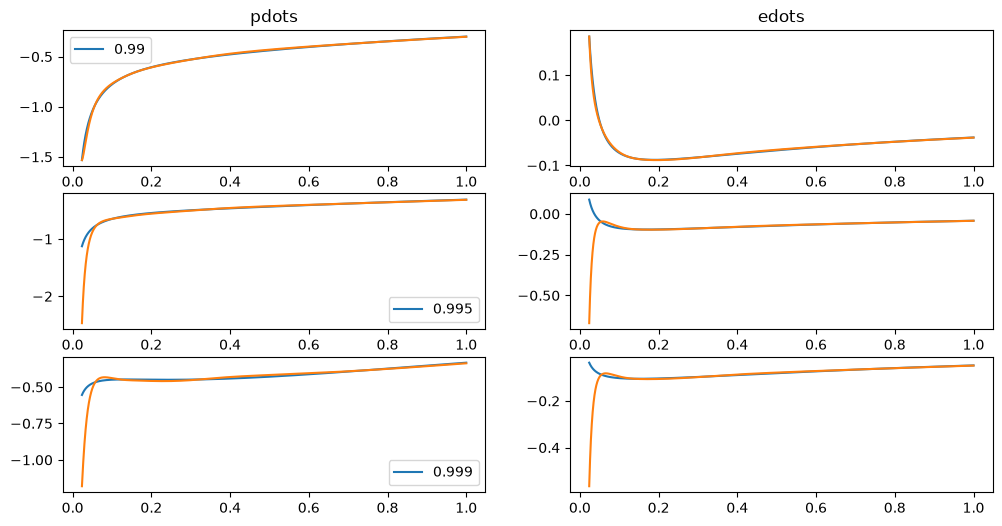

In [5]:
fig, axs = plt.subplots(3,2,figsize = (12,6))
a_vals = [0.99,0.995,0.999]

for i,aa in enumerate(a_vals):
    pdots_nex,pdots,edots_nex,edots,p,psep = compare(0.2,aa)

    axs[i,0].plot(p-psep, pdots, label = f"{aa}")
    axs[i,0].plot(p-psep, pdots_nex, label = f"")
    axs[i,1].plot(p-psep, edots, label = f"{aa}")
    axs[i,1].plot(p-psep, edots_nex, label = f"")

    axs[i,0].legend()

    
axs[0,0].set_title(r"pdots")
axs[0,1].set_title(r"edots")
    

In [10]:
pdotsA,pdotsB,edotsA,edotsB,p,psep = compare(0.1,0.99)

### use symmetric relative differnece: e = $\frac{2|A-B|}{|A|+|B|}$

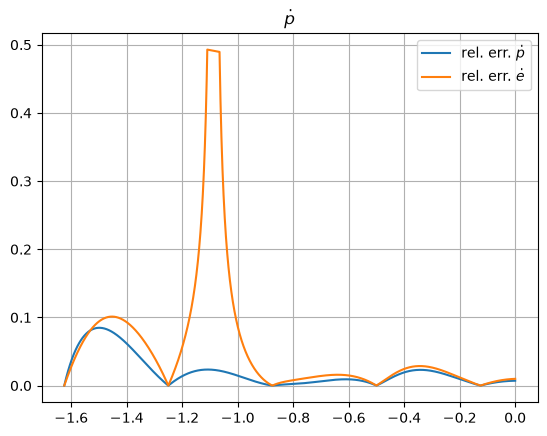

In [11]:
#plt.plot(p-psep,np.abs((pdotsA-pdotsB)/pdotsA),label = r"$\left|\frac{nex - few}{nex}\right|$")

#plt.plot(p-psep,pdotsB,label = "KerrEccEqFlux")
#plt.plot(p-psep,pdotsA,label = "NEX")

e_sym_diff = 2*np.abs(edotsA-edotsB)/(np.abs(edotsA)+np.abs(edotsB))
p_sym_diff = 2*np.abs(pdotsA-pdotsB)/(np.abs(pdotsA)+np.abs(pdotsB))

e_rel_diff = np.abs(edotsA-edotsB)/np.abs(edotsA)
p_rel_diff = np.abs(pdotsA-pdotsB)/np.abs(pdotsA)

#Remove points that are defintie singularities:
p1,p_rel_diff_clean = rem_sing(p,p_rel_diff,0.5)
p2,e_rel_diff_clean = rem_sing(p,e_rel_diff,0.5)


plt.plot(np.log10(p1-psep) , p_rel_diff_clean,label = r"rel. err. $\dot{p}$")
plt.plot(np.log10(p2-psep) , e_rel_diff_clean,label = r"rel. err. $\dot{e}$")

plt.legend()
plt.title(r"$\dot{p}$")
plt.grid()

#plt.ylim(-0,-00.05)
#plt.xlim(0,6*DELTAPMIN_REGIONC)


### What you see here is justa singularity, where $\dot{e}$ is 0, as can be seen below

Text(0, 0.5, '$\\dot{e}$')

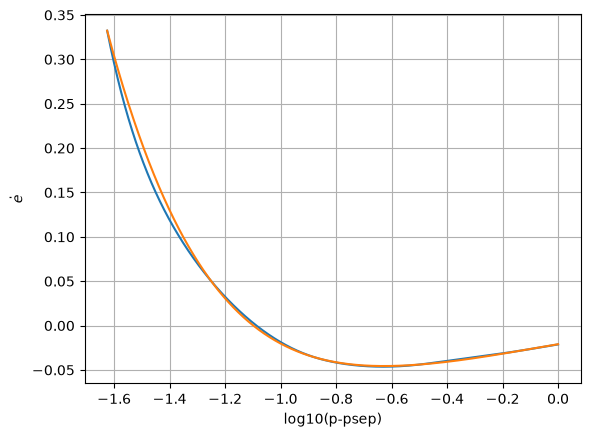

In [12]:
plt.plot(np.log10(p-psep),edotsA)
plt.plot(np.log10(p-psep),edotsB)
plt.grid()
plt.xlabel(r"log10(p-psep)")
plt.ylabel(r"$\dot{e}$")

In [7]:
n = np.argmax(np.abs((edotsA-edotsB)/edotsB))
edotsA[n],edotsB[n],p[n]

(np.float64(-0.00035767576375815243),
 np.float64(0.0005302789477128262),
 np.float64(1.5950100413407737))

(0.0, 0.14228242233969932)

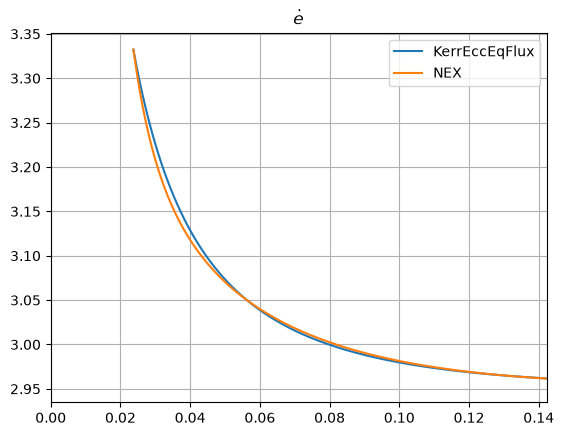

In [11]:
#plt.plot(p-psep,np.abs((edotsA-edotsB)/edotsA),label = r"$\left|\frac{nex - few}{nex}\right|$")

plt.plot(p-psep,edotsB,label = "KerrEccEqFlux")
plt.plot(p-psep,edotsA,label = "NEX")

plt.legend()
plt.grid()
plt.title(r"$\dot{e}$")

#plt.ylim(-0,-00.05)
plt.xlim(0,6*DELTAPMIN_REGIONC)

Both edot and pdot seems to disagree as a increases from 0.99. Keep in mind that a=0.99 is a point that the fluxes are calculated at, so we would expect them to agree here quite well, which they d0, but the next point at whivh they are evaluated at is around 0.9995. Check interpolation error

In [66]:
m1 = 1e6
m2 = 1e2
a = 0.999
e0 = 0.2
xI0 = 1.0  

pLSO = get_separatrix(a,e0,xI0)
p0=pLSO+DELTAPMIN_REGIONC*2

rhs1 = KerrEccEqFlux_nex(flux_output_convention="pex")
rhs2 = KerrEccEqFlux_nex(flux_output_convention="ELQ")

rhs1.add_fixed_parameters(m1, m2, a)
rhs2.add_fixed_parameters(m1, m2, a)

rhs1([p0, e0, xI0]),rhs2([p0, e0, xI0])

KerrEccEqFluxData_nex.h5
All good
KerrEccEqFluxData_nex.h5


(array([-0.53319105, -0.10492953,  0.        ,  0.4082485 ,  0.09796534,
         0.02501804]),
 array([-0.52485473, -0.1078442 ,  0.        ,  0.4082485 ,  0.09796534,
         0.02501804]))

In [67]:
nex_ELdot(a,p0,e0,xI0)

(-0.09445596888931589, -0.22911144502269487)

In [68]:
few_ELdot(a,p0,e0,xI0)

(-0.08397186403317643, -0.205034565681659)

## Directly compare Edot_interp functions in both models, E,L,p,e

In [3]:
ELQ = KerrEccEqFlux(flux_output_convention = "ELQ")
pex = KerrEccEqFlux(flux_output_convention = "pex")

ELQ_nex = KerrEccEqFlux_nex(flux_output_convention = "ELQ")
pex_nex = KerrEccEqFlux_nex(flux_output_convention = "pex")

KerrEccEqFluxData_nex.h5
KerrEccEqFluxData_nex.h5
All good


## Functions for calculating fluxes given (a,p,e,x):

In [30]:
def kerrecceqA(a,p,e,x):  # valid on p < plso +9.001
    pisco = get_separatrix(a,np.zeros_like(a),x)
    pLSO = get_separatrix(a,e,x)
    u,w,y,z = _uwyz_of_apex_kernel(a,p,e,x,pLSO,ALPHA_FLUX,BETA_FLUX)

    pn_term_p = 1#_pdot_PN(p,e,pisco,pLSO)
    pn_term_e = 1#_edot_PN(p,e,pisco,pLSO)
    
    
    Edot_interp = ELQ.Edot_interp_A
    Ldot_interp = ELQ.Ldot_interp_A
    pdot_interp = pex.pdot_interp_A
    edot_interp = pex.edot_interp_A

    return Edot_interp(u,w,z), Ldot_interp(u,w,z), -pdot_interp(u,w,z)*pn_term_p, -edot_interp(u,w,z)*pn_term_e,[u,w,y,z],pLSO


def nex(a,p,e,x):
    
    pisco = get_separatrix(a,np.zeros_like(a),x)
    pLSO = get_separatrix(a,e,x)
    u,w,y,z = _uwyz_of_apex_kernel_nex(a,p,e,x,pLSO,ALPHA_FLUX,BETA_FLUX)
    
    pn_term_p = 1#_pdot_PN(p,e,pisco,pLSO)
    pn_term_e = 1#_edot_PN(p,e,pisco,pLSO)
    
    Edot_interps = ELQ_nex.Edot_interp_A
    Ldot_interps = ELQ_nex.Ldot_interp_A
    pdot_interps = pex_nex.pdot_interp_A
    edot_interps = pex_nex.edot_interp_A

    return Edot_interps(u,w,z), Ldot_interps(u,w,z), -pdot_interps(u,w,z)*pn_term_p, -edot_interps(u,w,z)*pn_term_e,[u,w,y,z]   

def nex_pedot(a,p,e,x): #Returns the actual rhs used to make traj
    psep = get_separatrix(a,e,x)
    pisco = get_separatrix(a,np.zeros_like(a),x)
    u,w,y,z = _uwyz_of_apex_kernel_nex(a,p,e,x,psep,ALPHA_FLUX,BETA_FLUX)

    pn_term_p = _pdot_PN(p,e,pisco,psep)
    pn_term_e = _edot_PN(p,e,pisco,psep)

    pdot_interps = pex_nex.pdot_interp_A
    edot_interps = pex_nex.edot_interp_A

    return -pdot_interps(u,w,z)*pn_term_p , -edot_interps(u,w,z)*pn_term_e 
    
def few_pedot(a,p,e,x): #Returns the actual rhs used to make traj
    psep = get_separatrix(a,e,x)
    pisco = get_separatrix(a,np.zeros_like(a),x)
    u,w,y,z = _uwyz_of_apex_kernel(a,p,e,x,psep,ALPHA_FLUX,BETA_FLUX)

    pn_term_p = _pdot_PN(p,e,pisco,psep)
    pn_term_e = _edot_PN(p,e,pisco,psep)

    pdot_interps = pex.pdot_interp_A
    edot_interps = pex.edot_interp_A

    return -pdot_interps(u,w,z)*pn_term_p , -edot_interps(u,w,z)*pn_term_e 

def nex_ELdot(a,p,e,x): #Returns the actual rhs used to make traj
    psep = get_separatrix(a,e,x)
    pisco = get_separatrix(a,np.zeros_like(a),x)
    u,w,y,z = _uwyz_of_apex_kernel_nex(a,p,e,x,psep,ALPHA_FLUX,BETA_FLUX)

    EdotPN, LdotPN = _PN_alt(p, e)

    Edot_interps = ELQ_nex.Edot_interp_A
    Ldot_interps = ELQ_nex.Ldot_interp_A

    return -Edot_interps(u,w,z)*EdotPN , -Ldot_interps(u,w,z)*LdotPN

def nex_ELdot_uwz(u,w,z):
    u,w,y,z  = np.asarray(u),np.asarray(w),np.asarray(1),np.asarray(z)
    a,p,e,x = apex_of_uwyz_nex(u,w,y,z)
    return nex_ELdot(a,p,e,x)

def few_ELdot(a,p,e,x): #Returns the actual rhs used to make traj
    psep = get_separatrix(a,e,x)
    pisco = get_separatrix(a,np.zeros_like(a),x)
    u,w,y,z = _uwyz_of_apex_kernel(a,p,e,x,psep,ALPHA_FLUX,BETA_FLUX)

    EdotPN, LdotPN = _PN_alt(p, e)

    Edot_interps = ELQ.Edot_interp_A
    Ldot_interps = ELQ.Ldot_interp_A

    return -Edot_interps(u,w,z)*EdotPN , -Ldot_interps(u,w,z)*LdotPN
    

In [13]:
_PN_alt(p0+12,e0+0.3)

(0.0, 0.0002501009105912027)

Text(0.5, 0.98, 'Relative errors in all fluxes. (With normalisation by PN terms)')

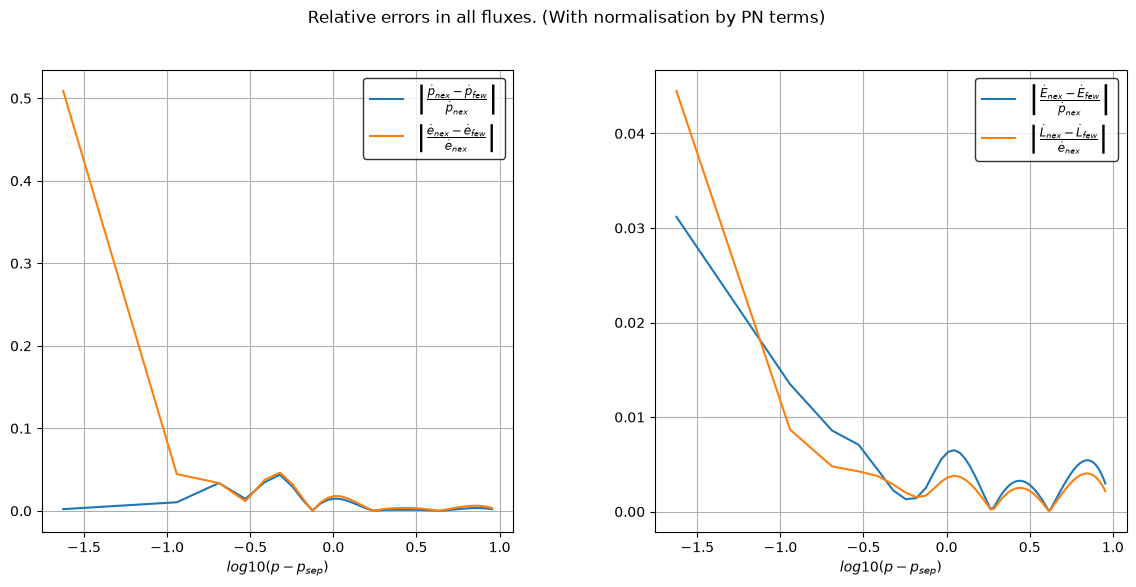

In [197]:
a,e,x = 0.999,0.1,1
pLSO = get_separatrix(a,e,x)


p = np.linspace(pLSO+DELTAPMIN_REGIONC, pLSO+9.001,100)  #Evaluate on a smaller grid to avoid singularities

fig, axs = plt.subplots(1,2)
plt.subplots_adjust(wspace=0.3)
fig.set_size_inches(14, 6)


pdot_rel_error = np.abs(( nex(a,p,e,x)[2]-kerrecceqA(a,p,e,x)[2])/nex(a,p,e,x)[2])
edot_rel_error = np.abs(( nex(a,p,e,x)[3]-kerrecceqA(a,p,e,x)[3])/kerrecceqA(a,p,e,x)[3])   
Edot_rel_error = np.abs(( nex(a,p,e,x)[0]-kerrecceqA(a,p,e,x)[0])/nex(a,p,e,x)[0])
Ldot_rel_error = np.abs(( nex(a,p,e,x)[1]-kerrecceqA(a,p,e,x)[1])/nex(a,p,e,x)[1])
#print(kerrecceqA(a,p,e,x)[3])
#print(nex(a,p,e,x)[3])

axs[0].plot(np.log10(p-pLSO),pdot_rel_error,label=r"$\left|\frac{\dot{p}_{nex} - \dot{p}_{few}}{\dot{p}_{nex}}\right|$")
axs[0].plot(np.log10(p-pLSO),edot_rel_error,label=r"$\left|\frac{\dot{e}_{nex} - \dot{e}_{few}}{\dot{e}_{nex}}\right|$")

axs[0].legend(fontsize = "large",edgecolor = "black")
axs[0].grid()
axs[0].set_xlabel(r"$log10(p-p_{sep})$")


axs[1].plot(np.log10(p-pLSO),Edot_rel_error,label=r"$\left|\frac{\dot{E}_{nex} - \dot{E}_{few}}{\dot{p}_{nex}}\right|$")
axs[1].plot(np.log10(p-pLSO),Ldot_rel_error,label=r"$\left|\frac{\dot{L}_{nex} - \dot{L}_{few}}{\dot{e}_{nex}}\right|$")

axs[1].legend(fontsize = "large",edgecolor = "black")
axs[1].grid()
axs[1].set_xlabel(r"$log10(p-p_{sep})$")
fig.suptitle("Relative errors in all fluxes. (With normalisation by PN terms)")

#axs[0].set_xlim(0,0.2)


In [86]:
e,a = 0.1,0.99
pdot,pdot_nex,edot,edot_nex,p,psep= compare(e,a)

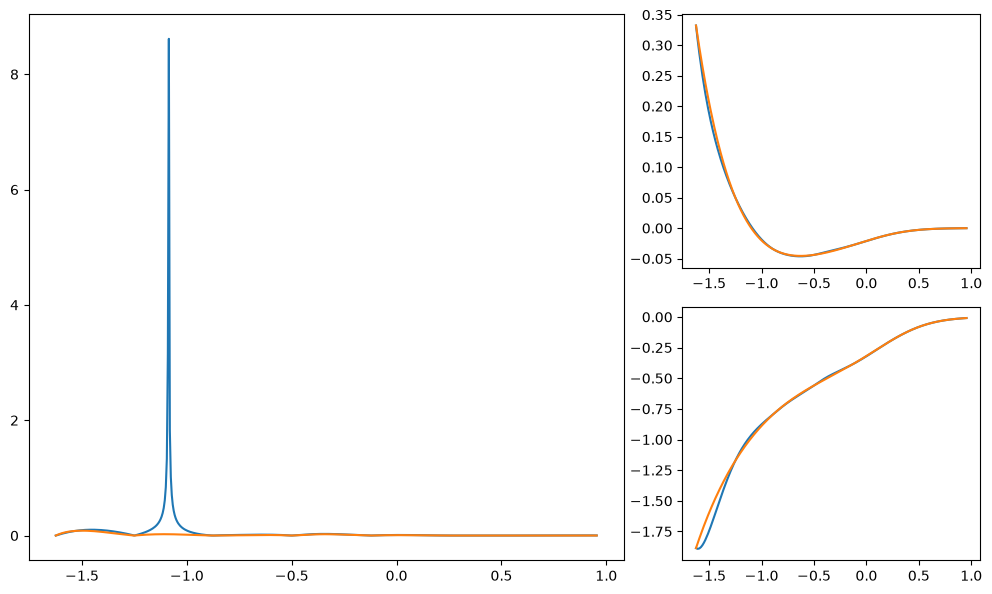

In [87]:
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])

# Large plot on the left
ax_main = fig.add_subplot(gs[:, 0])

# Two smaller plots on the right
ax_top = fig.add_subplot(gs[0, 1])
ax_bottom = fig.add_subplot(gs[1, 1])

ax_main.plot(np.log10(p-psep),np.abs((edot-edot_nex)/edot))
ax_main.plot(np.log10(p-psep),np.abs((pdot-pdot_nex)/pdot))
ax_top.plot(np.log10(p-psep),edot)
ax_top.plot(np.log10(p-psep),edot_nex)
ax_bottom.plot(np.log10(p-psep),pdot)
ax_bottom.plot(np.log10(p-psep),pdot_nex)

plt.tight_layout()
plt.show()

Much bigger error for a = 0.999, than =0.99

# Inspirals:

In [2]:
insp_nex = EMRIInspiral(func=KerrEccEqFlux_nex)
insp = EMRIInspiral(func=KerrEccEqFlux)
rhs_nex = KerrEccEqFlux_nex()

KerrEccEqFluxData_nex.h5
All good
KerrEccEqFluxData_nex.h5
All good


#### KerrEccEq model comparison:

In [3]:
m1 = 1e6
m2 = 1e2
a = 0.999
e0 = 0.0
xI0 = 1.0  

pLSO = get_separatrix(a,e0,xI0)
p0=pLSO+5

T = 1  #

traj_pars = [m1, m2, a, p0, e0, xI0]

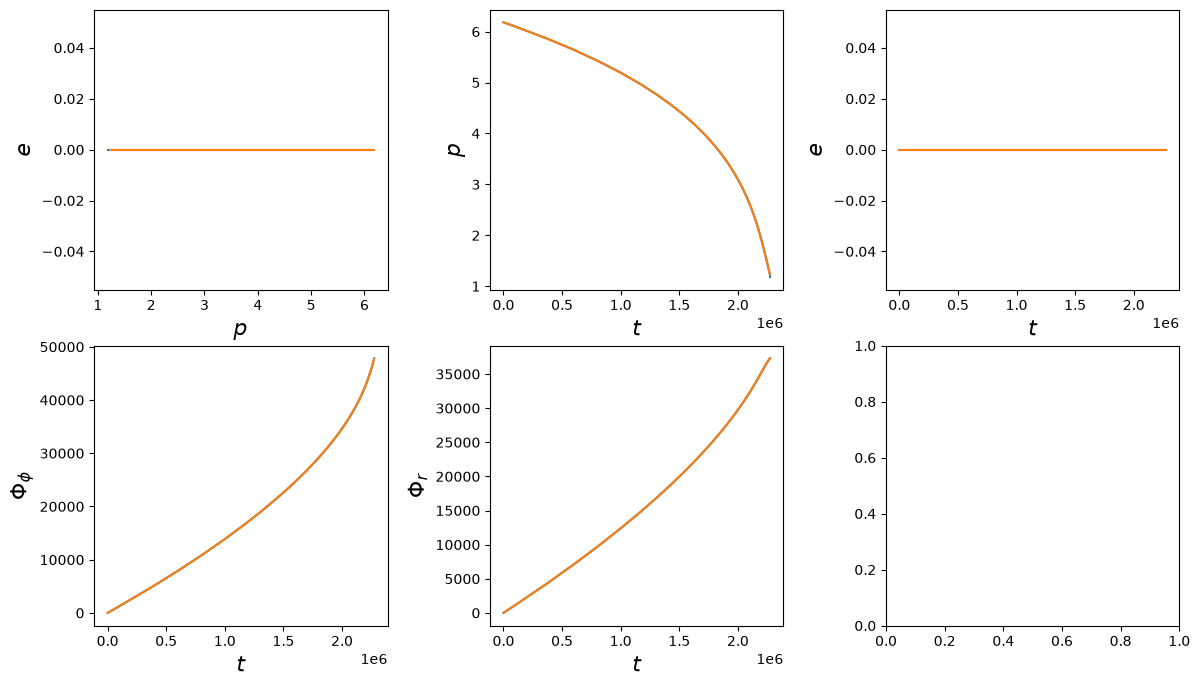

In [39]:
t, p, e, xI, Phi_phi, Phi_theta, Phi_r = insp(*traj_pars, T=T,)
t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars, T=T,)

Omega_phi, Omega_theta, Omega_r = get_fundamental_frequencies(a,p,e,xI)

fig, axes = plt.subplots(2, 3)
plt.subplots_adjust(wspace=0.35)
fig.set_size_inches(14, 8)
axes = axes.ravel()

ylabels = [ r"$e$", r"$p$", r"$e$", r"$\Phi_\phi$", r"$\Phi_r$"]
xlabels = [ r"$p$", r"$t$", r"$t$", r"$t$", r"$t$"]
ys = [e, p, e, Phi_phi, Phi_theta, Phi_r]
xs = [p, t, t, t, t, t]

y2s = [e2, p2, e2, Phi_phi2, Phi_theta2, Phi_r2]
x2s = [p2, t2, t2, t2, t2, t2]

for i, (ax, x, y, xlab, ylab,x2,y2) in enumerate(zip(axes, xs, ys, xlabels, ylabels,x2s,y2s)):
    ax.plot(x, y)
    ax.plot(x2, y2)
    ax.set_xlabel(xlab, fontsize=16)
    ax.set_ylabel(ylab, fontsize=16)

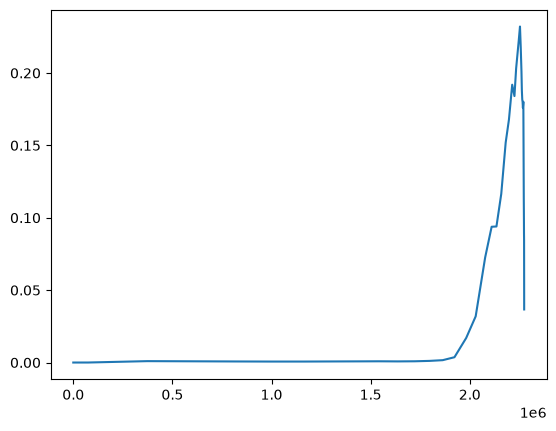

In [43]:
p1,p2,lenp  = shrink_match(p,p2)

plt.plot(t[:lenp],np.abs((p1-p2)/p1))

#### Vary e;

1.0015896068752117 1.0799701770205519
1.075181936824412 1.0751145010465148
1.1501423879696715 1.1221210403317965
1.2251278246291142 1.1598018213203647
1.3001210226820088 1.2450281493462823


(0.0, 100000.0)

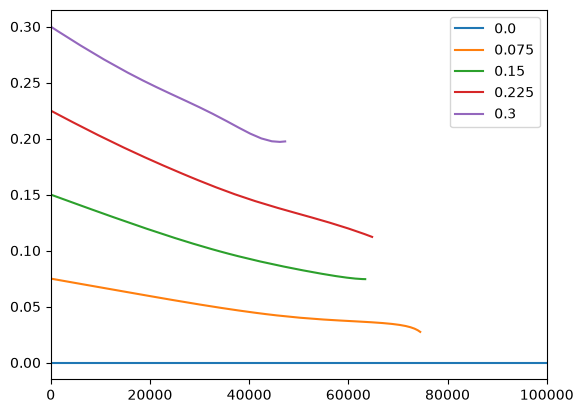

In [46]:
#a_vals =[0.99,0.999,0.9999,0.999999,1-10**(-10)]
e_vals =np.linspace(0.0,0.3,5)
for e_val in e_vals:
    m1 = 1e6
    m2 = 1e2
    a = 1-10**(-9)
    e0 = e_val
    xI0 = 1.0  
    
    pLSO = get_separatrix(a,e0,xI0)
    p0=1.5
    
    T = 1.4  #
    
    traj_pars = [m1, m2, a, p0, e0, xI0]
    
    t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars, T=T)

    #pdot,edot,_,_,_,_ = insp_nex.func(np.array([p2,e2,1]))

    plt.plot(t2,e2,label = f"{round(e_val,3)}")

    end_plso = get_separatrix(a,e2[-1],1)
   # plt.scatter(t2[-1],end_plso+2*DELTAPMIN_REGIONC,s=2)

    insp_nex.func

    print(pLSO,p2[-1])

plt.legend()
plt.xlim(0,1e5)

#### Vary a;

In [4]:
rhs_nex = KerrEccEqFlux_nex()

KerrEccEqFluxData_nex.h5
All good


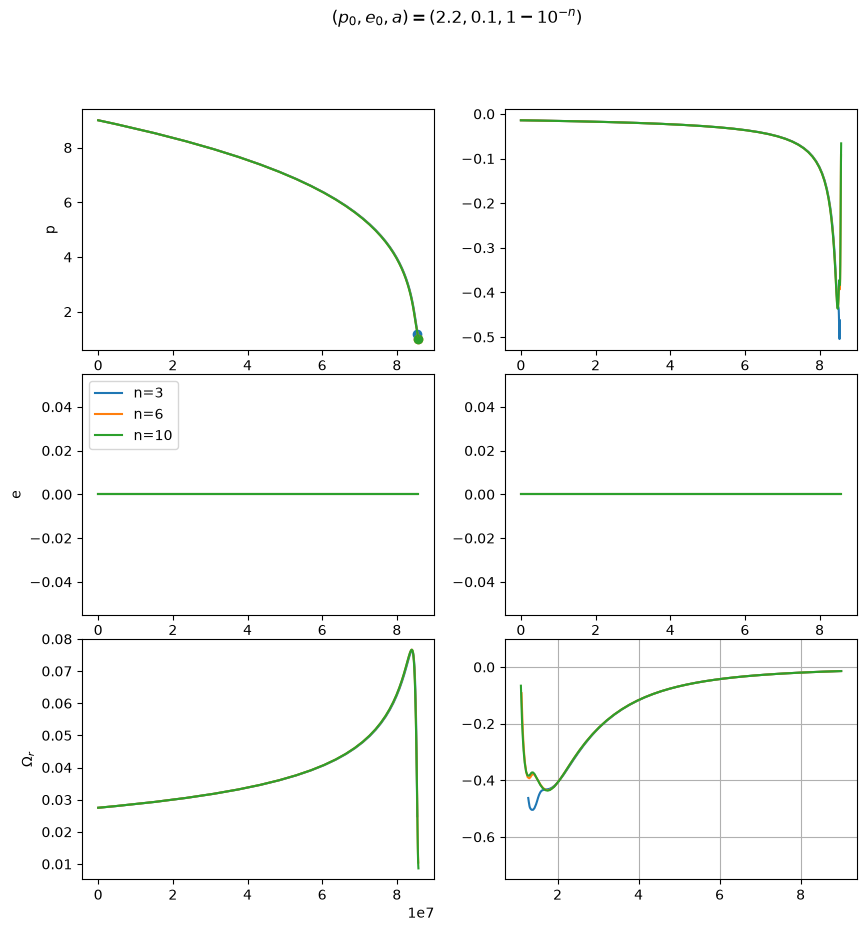

In [5]:
fig,axs = plt.subplots(3,2,figsize = (10,10))

#a = 1 - 10**(-n)
n_vals = [3,6,10]

for n in n_vals:
    m1 = 1e6
    m2 = 1e1
    a = 1 - 10**(-n)
    e0 = 0.0
    xI0 = 1.0  
    rhs_nex.add_fixed_parameters(m1, m2, a)
    pLSO = get_separatrix(a,e0,xI0)
    p0=9
    
    T = 6  #
    
    traj_pars = [m1, m2, a, p0, e0, xI0]
    
    t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars, T=T)

    Omega_phi, Omega_theta, Omega_r = get_fundamental_frequencies(a,p2,e2,xI2)

    axs[0,0].plot(t2,p2,label = f"n= {round(-n,3)}")
    axs[1,0].plot(t2,e2,label = f"n={round(n,3)}")
    axs[2,0].plot(t2,Omega_r,label = f"{round(n,3)}")
   # axs[3,0].plot(t2,Omega_phi,label = f"{round(n,3)}")

    pdots = []
    edots = []
    for p,e in zip(p2,e2):
        pdots.append(rhs_nex([p, e, 1])[0])
        edots.append(rhs_nex([p, e, 1])[1])



    axs[0,1].plot(t2,pdots)
    axs[1,1].plot(t2,edots)

    axs[2,1].plot(p2,pdots)

    axs[0,0].scatter(t2[-1],get_separatrix(a,e2[-1],1))

   # print(pLSO,p2[-1])

axs[1,0].legend(loc ="upper left")
axs[0,0].set_ylabel("p")
axs[1,0].set_ylabel("e")
axs[2,0].set_ylabel(r"$\Omega_{r}$")
#axs[3,0].set_ylabel(r"$\Omega_{\phi}$")
#axs[3,0].set_xlabel(r"t")

plt.subplots_adjust(hspace=0.1)
fig.suptitle(r"$(p_0,e_0,a) = \left(2.2,0.1,1-10^{-n}\right)$")

#axs[0].set_xlim(0.1*1e7)
axs[2,1].set_ylim(-0.75,0.1)
axs[2,1].grid()

-0.4682885547586056 2.0
-0.2566997296725885 1.2106505703684405
-0.16568699777420412 1.153594742509972
-0.16928169307726124 1.14598734793946


Text(0.5, 0.98, '$(p_0, e_0, a) = \\left(2, 0.2, 1-10^{-n}\\right)$')

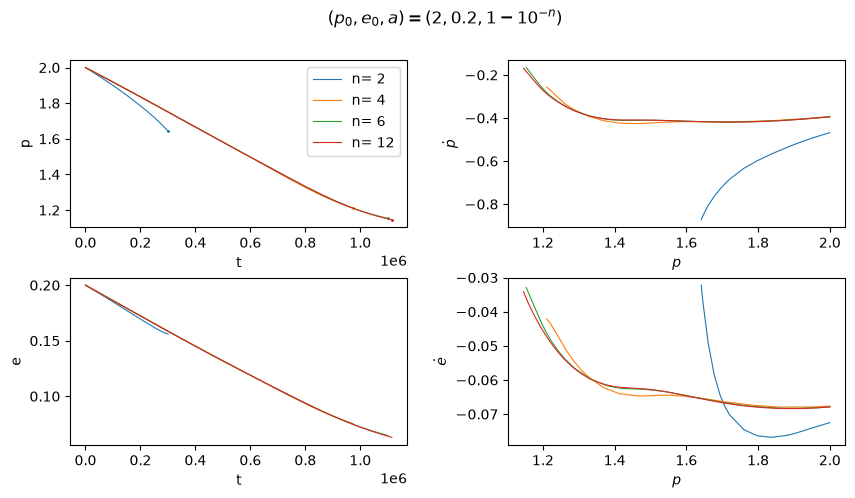

In [5]:
fig,axs = plt.subplots(2,2,figsize = (10,5))

#a = 1 - 10**(-n)
n_vals = [2,4,6,12]

for n in n_vals:
    m1 = 1e6
    m2 = 1e1
    a = 1 - 10**(-n)
    e0 = 0.2
    xI0 = 1.0  
    rhs_nex.add_fixed_parameters(m1, m2, a)
    pLSO = get_separatrix(a,e0,xI0)
    p0=2
    
    T = 1  #
    
    traj_pars = [m1, m2, a, p0, e0, xI0]
    
    t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars, T=T)

    Omega_phi, Omega_theta, Omega_r = get_fundamental_frequencies(a,p2,e2,xI2)

    pdots = []
    edots = []
    for p,e in zip(p2,e2):
        pdots.append(rhs_nex([p, e, 1])[0])
        edots.append(rhs_nex([p, e, 1])[1])
    print(max(pdots),p2[np.argmax(pdots)])

    lws=0.8

    axs[0,0].plot(t2,p2,label = f"n= {round(n,3)}",lw=lws)
    axs[0,1].plot(p2,pdots,lw=lws)
    axs[1,0].plot(t2,e2,label = f"n={round(n,3)}",lw=lws)
    axs[1,1].plot(p2,edots,label = f"{round(n,3)}",lw=lws)

    axs[0,1].set_ylabel(r"$\dot{p}$")
    axs[1,1].set_ylabel(r"$\dot{e}$")
    axs[0,1].set_xlabel(r"$p$")
    axs[1,1].set_xlabel(r"$p$")


    axs[0,0].scatter(t2[-1],get_separatrix(a,e2[-1],1)+3.5*DELTAPMIN_REGIONC,s=1.2)


   # print(pLSO,p2[-1])

#axs[1,0].legend(loc ="upper left")
axs[0,0].set_ylabel("p")
axs[1,0].set_ylabel("e")
axs[0,0].set_xlabel("t")
axs[1,0].set_xlabel("t")
axs[0,0].legend()
#axs[0,1].set_ylim(-0.01,0.01)

plt.subplots_adjust(hspace=0.3)
plt.subplots_adjust(wspace=0.3)
fig.suptitle(rf"$(p_0, e_0, a) = \left({p0}, {e0}, 1-10^{{-n}}\right)$")

#fig.savefig(f"Trajplot_e0={e0}_p0={p0}.png", dpi=300, bbox_inches="tight")

In [7]:
4*DELTAPMIN_REGIONC

0.09485494822646622

In [7]:
rhs_nex = KerrEccEqFlux_nex()
rhs_nex_ELQ = KerrEccEqFlux_nex(flux_output_convention="ELQ")
def flux(a,p,e,x):
    rhs_nex.add_fixed_parameters(m1, m2, a)
    pdot = rhs_nex([p, e, x])[0]
    edot = rhs_nex([p, e, x])[1]

    rhs_nex_ELQ.add_fixed_parameters(m1, m2, a)
    Edot = rhs_nex_ELQ([p, e, x])[0]
    Ldot = rhs_nex_ELQ([p, e, x])[1]

    return pdot, edot ,Edot,Ldot

        
    

KerrEccEqFluxData_nex.h5
All good
KerrEccEqFluxData_nex.h5


In [ ]:
flux()

In [29]:
rhs_nex = KerrEccEqFlux_nex()
m1=1e2
m2=1e6
a=0.9999

rhs_nex.add_fixed_parameters(m1, m2, a)

rhs_nex([6, 0.2, 1])

KerrEccEqFluxData_nex.h5
All good


array([-0.04207608, -0.00227285,  0.        ,  0.06099999,  0.05488644,
        0.04135894])

In [30]:
nex_pedot(0.9999,6,0.2,1)

(array([-0.04207608]), array([-0.00227285]))

NameError: name 'insp_nex' is not defined

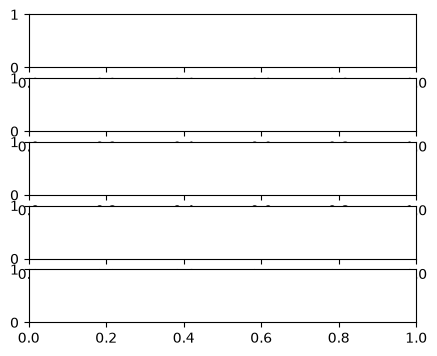

In [71]:
fig,axs = plt.subplots(5,1,figsize = (5,4))
a_vals = [0.99,0.999,0.9999,0.999999,1-10**(-12)]
#e_vals =np.linspace(0.0,0.3,3)
e_vals = [0.1,0.2,0.3,0.4]


#a = 1 - 10**(-n)
n_vals = [2,6,10,12]

for e in e_vals:
    m1 = 1e6
    m2 = 1e2
    a = 1 - 10**(-3)
    e0 = e
    xI0 = 1.0  
    
    pLSO = get_separatrix(a,e,xI0)
    p0=2
    
    T = 0.02  #
    
    traj_pars = [m1, m2, a, p0, e0, xI0]
    
    t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars, T=T)

    Omega_phi, Omega_theta, Omega_r = get_fundamental_frequencies(a,p2,e2,xI2)

    axs[0].plot(t2,p2,label = f"e= {round(e,2)}")
    axs[1].plot(t2,e2,label = f"e={round(e,2)}")
    axs[2].plot(t2,Omega_r,label = f"")
    axs[3].plot(t2,Omega_phi,label = f"")
    axs[4].plot(t2,Omega_theta,label = f"")

   # axs[0].plot(t2,np.ones_like(t2)*(pLSO+DELTAPMIN_REGIONC))

   # print(pLSO,p2[-1])

axs[0].legend(loc ="lower left")
axs[0].set_ylabel("p")
axs[1].set_ylabel("e")
axs[2].set_ylabel(r"$\Omega_{r}$")
axs[3].set_ylabel(r"$\Omega_{\phi}$")
axs[3].set_xlabel(r"t")

axs[0].set_xlim(0,100000)
axs[1].set_xlim(0,100000)
axs[2].set_xlim(0,100000)
axs[3].set_xlim(0,100000)
axs[4].set_xlim(0,100000)

plt.subplots_adjust(hspace=0.1)
fig.suptitle(r"$(p_0,a) = \left(2.2,1-10^{-10}\right)$")

In [ ]:
pex_nex = KerrEccEqFlux_nex(flux_output_convention = "pex")

In [ ]:
pex_nex.pdot_interp_A(0.6491102221017462, 0.0, 0.7999992278115937)

# Contour plots e,a vs pdot and edot

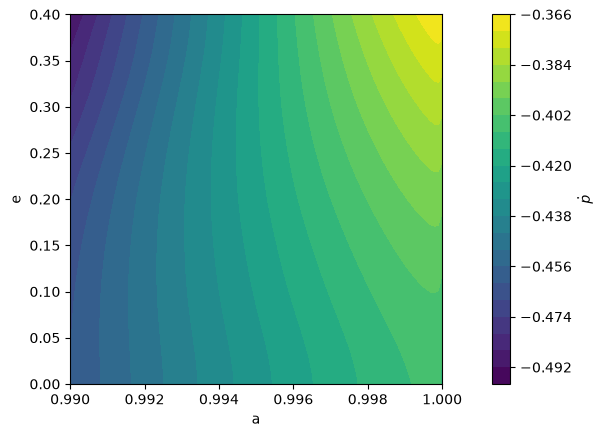

In [32]:
p=2
n1,n2 =100,100
a = np.linspace(0.99, 1-10**(-12), n1)
e = np.linspace(0, 0.4, n2)
A, E = np.meshgrid(a, e)

Z =nex_pedot(A.flatten(),(np.ones_like(A)*p).flatten(),E.flatten(),np.ones_like(E).flatten())#get_separatrix(A.flatten(),E.flatten(),np.ones_like(A).flatten()) # nex_pedot(A,np.ones_like(A)*6,E,np.ones_like(E))
Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

fig, ax = plt.subplots()

cf1 = ax.contourf(A, E, Z_p, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax, label=r"$\dot{p}$",pad = 0.1)

ax.set_xlabel("a")
ax.set_ylabel("e")



plt.show()

Text(0, 0.5, 'e')

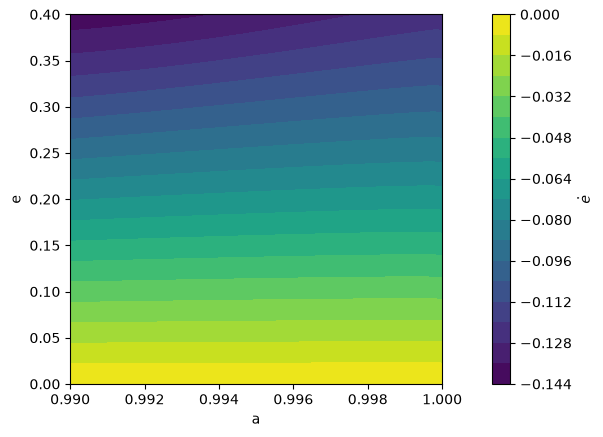

In [33]:

fig, ax = plt.subplots()

cf2 = ax.contourf(A, E, Z_e, levels=20, cmap="viridis")
fig.colorbar(cf2, ax=ax, label=r"$\dot{e}$",pad = 0.1)

ax.set_xlabel("a")
ax.set_ylabel("e")

## Contour plots of pdot and edot, p vs a

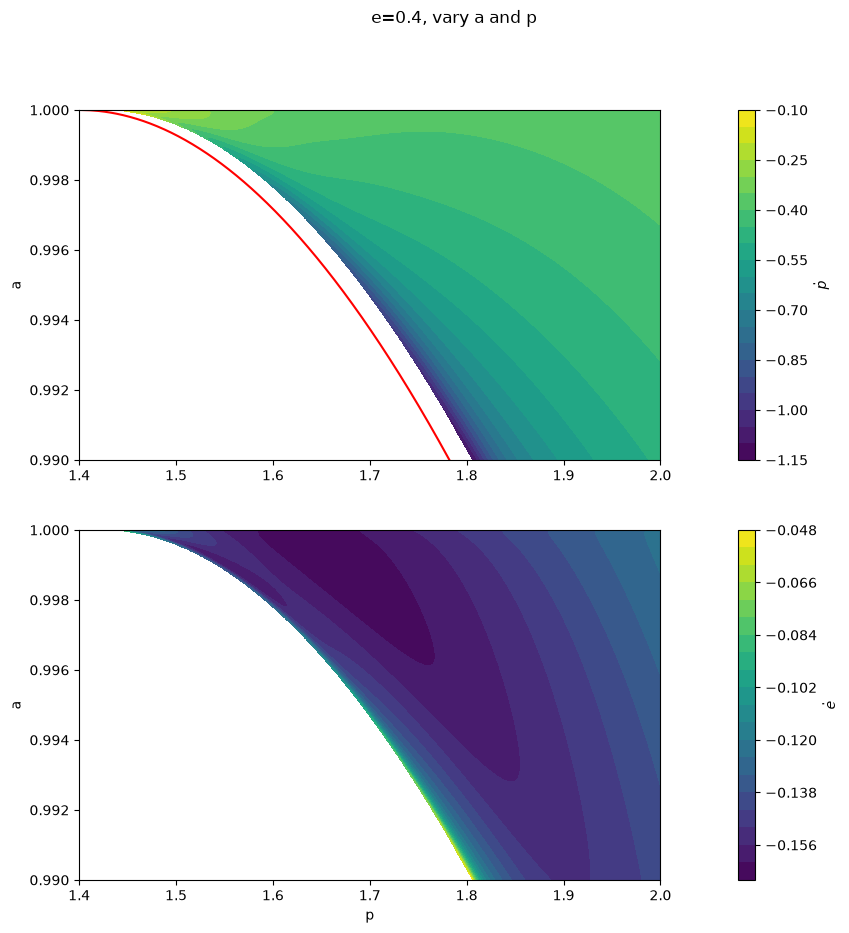

In [61]:
x=1
e=0.4
n1,n2 =1000,1000

a = np.linspace(0.99, 1-10**(-12), n1)
p= np.linspace(1.4,2,n2)

A, P = np.meshgrid(a, p)

Z =nex_pedot(A.flatten(),P.flatten(),np.ones_like(A.flatten())*e,np.ones_like(A).flatten())

PSEP = get_separatrix(A.flatten(),(np.ones_like(A)*e).flatten(),np.ones_like(A).flatten())
PSEP = PSEP.reshape(n1,n2)



Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

Zp_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p, np.nan)
Ze_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e, np.nan)

fig, ax = plt.subplots(2,1,figsize=(10,10))

cf1 = ax[0].contourf(P, A, Zp_masked, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"$\dot{p}$",pad = 0.1)

cf2 = ax[1].contourf(P, A, Ze_masked, levels=20, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"$\dot{e}$",pad = 0.1)

#ax[0].set_xlabel("p")
ax[0].set_ylabel("a")
ax[1].set_xlabel("p")
ax[1].set_ylabel("a")

ax[0].plot(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1),a,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"e={e}, vary a and p")
plt.show()

## Contour plots of pdot and edot, p vs e

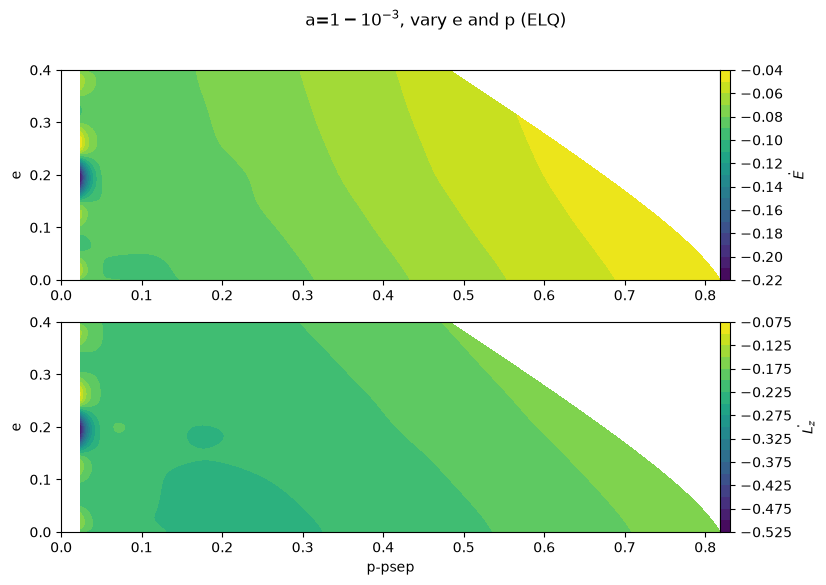

In [118]:
x=1
n=3
a=1-10**(-n)
n1,n2 =1000,1000

e = np.linspace(0, 0.4, n1)
psep_min = min(get_separatrix(a,e,x))
p= np.linspace(1,2,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z = nex_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())   #flux takes apex, spits out pdot, edot, Edot,Ldot

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

Zp_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p, np.nan)
Ze_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e, np.nan)


fig, ax = plt.subplots(2,1,figsize = (10,6))

cf1 = ax[0].contourf(P-PSEP, E, Zp_masked, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"$\dot{E}$",pad = 0)
cf2 = ax[1].contourf(P-PSEP, E, Ze_masked, levels=20, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"$\dot{L_{z}}$",pad = 0)

ax[0].set_xlim(0)
ax[1].set_xlim(0)

ax[0].set_ylabel("e")

ax[1].set_xlabel("p-psep")
ax[1].set_ylabel("e")

#ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"a=$1-10^{{-{n}}}$, vary e and p (ELQ)")
plt.show()
fig.savefig(f"contourplot_e_vs_p_n={n}_compare_with_few_ELQ.png", dpi=300, bbox_inches="tight")


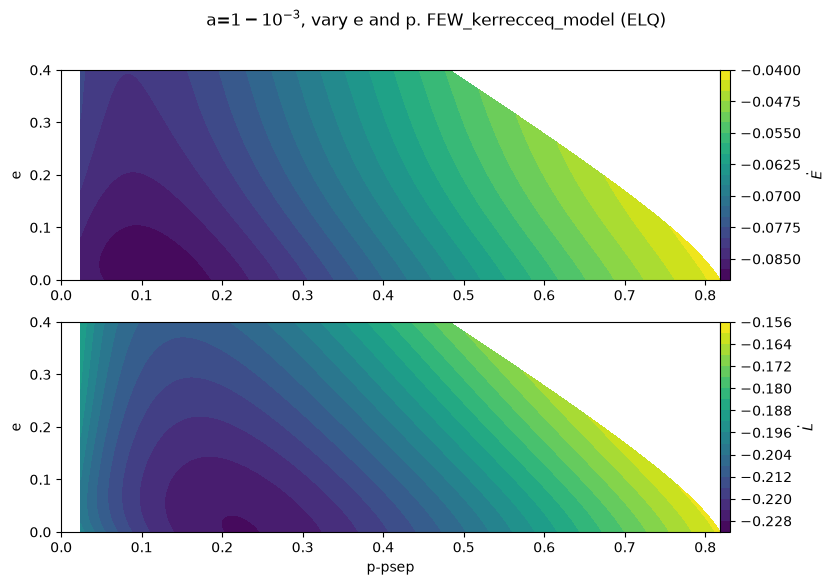

In [116]:
x=1
n=3
a=1-10**(-n)
n1,n2 =1000,1000

e = np.linspace(0, 0.4, n1)
psep_min = min(get_separatrix(a,e,x))
p= np.linspace(1,2,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z = few_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

Zp_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p, np.nan)
Ze_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e, np.nan)


fig, ax = plt.subplots(2,1,figsize = (10,6))

cf1 = ax[0].contourf(P-PSEP, E, Zp_masked, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"$\dot{E}$",pad = 0)
cf2 = ax[1].contourf(P-PSEP, E, Ze_masked, levels=20, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"$\dot{L}$",pad = 0)

ax[0].set_xlim(0)
ax[1].set_xlim(0)

ax[0].set_ylabel("e")

ax[1].set_xlabel("p-psep")
ax[1].set_ylabel("e")

#ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"a=$1-10^{{-{n}}}$, vary e and p. FEW_kerrecceq_model (ELQ)")
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_FEW_ELQ.png", dpi=300, bbox_inches="tight")

In [149]:
a,e,x = 0.999999999999,0.3,1
pLSO = get_separatrix(a,e,x)
p=pLSO+DELTAPMAX_REGIONC

_uwyz_of_apex_kernel_nex(a,p,e,x,pLSO,ALPHA_FLUX,BETA_FLUX)

NameError: name 'DELTAPMAX_REGIONC' is not defined

In [124]:
'''
import matplotlib.animation as animation

fig, ax = plt.subplots()

def update(param):
    ax.clear()
    a=1-10**(-param)
    n1,n2 =1000,1000
    
    e = np.linspace(0, 0.4, n1)
    psep_min = min(get_separatrix(a,e,x))
    p= np.linspace(1,2,n2)
    
    E, P = np.meshgrid(e, p)
    A= np.ones_like(P)*a
    X= np.ones_like(P)
    
    Z = nex_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten())
    
    PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
    PSEP = PSEP.reshape(n1,n2)
    
    Z_p = Z[0].reshape(n1,n2)
    Z_e = Z[1].reshape(n1,n2)
    
    Zp_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p, np.nan)
    Ze_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e, np.nan)

    plt.suptitle(rf"a=$1-10^{{-{param}}}$, vary e and p")
    cf1 = ax.contourf(P-PSEP, E, Zp_masked, levels=10, cmap="viridis")
    #fig.colorbar(cf1, ax=ax, label=r"$\dot{p}$",pad = 0)


    return []

params = np.linspace(2, 12, 12)

ani = animation.FuncAnimation(
    fig,
    update,
    frames=params,
    interval=100
)

ani.save("contour_animation.gif", writer="pillow", fps=10)
'''

<>:32: SyntaxWarning: invalid escape sequence '\d'
<>:32: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2678/811384434.py:32: SyntaxWarning: invalid escape sequence '\d'
  #fig.colorbar(cf1, ax=ax, label=r"$\dot{p}$",pad = 0)


'\nimport matplotlib.animation as animation\n\nfig, ax = plt.subplots()\n\ndef update(param):\n    ax.clear()\n    a=1-10**(-param)\n    n1,n2 =1000,1000\n\n    e = np.linspace(0, 0.4, n1)\n    psep_min = min(get_separatrix(a,e,x))\n    p= np.linspace(1,2,n2)\n\n    E, P = np.meshgrid(e, p)\n    A= np.ones_like(P)*a\n    X= np.ones_like(P)\n\n    Z = nex_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten())\n\n    PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())\n    PSEP = PSEP.reshape(n1,n2)\n\n    Z_p = Z[0].reshape(n1,n2)\n    Z_e = Z[1].reshape(n1,n2)\n\n    Zp_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p, np.nan)\n    Ze_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e, np.nan)\n\n    plt.suptitle(rf"a=$1-10^{{-{param}}}$, vary e and p")\n    cf1 = ax.contourf(P-PSEP, E, Zp_masked, levels=10, cmap="viridis")\n    #fig.colorbar(cf1, ax=ax, label=r"$\\dot{p}$",pad = 0)\n\n\n    return []\n\nparams = np.linspace(2, 12, 12)\n\nan

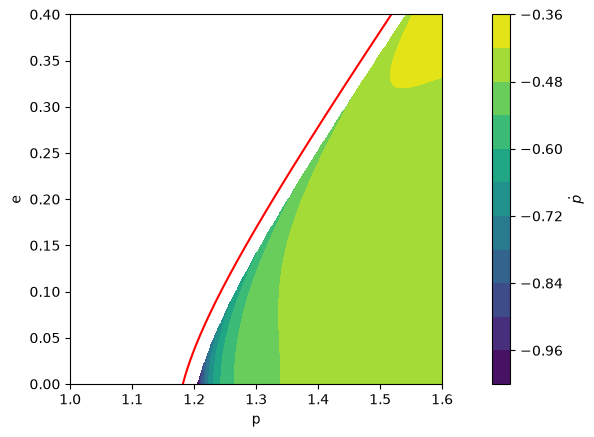

In [36]:
x=1
a=1-10**(-3)
n1,n2 =400,400

e = np.linspace(0, 0.4, n1)
p= np.linspace(1,1.6,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z = (few_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten()))

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

Zp_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p, np.nan)
Ze_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e, np.nan)

fig, ax = plt.subplots()

cf1 = ax.contourf(P, E, Zp_masked, levels=10, cmap="viridis")
fig.colorbar(cf1, ax=ax, label=r"$\dot{p}$",pad = 0.1)

ax.set_xlabel("p")
ax.set_ylabel("e")

ax.plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC,0, 0.4, color="grey", alpha=0.3, hatch="//")

plt.show()

## Relative differneces between nex and few in edot and pdot, plotted p vs e

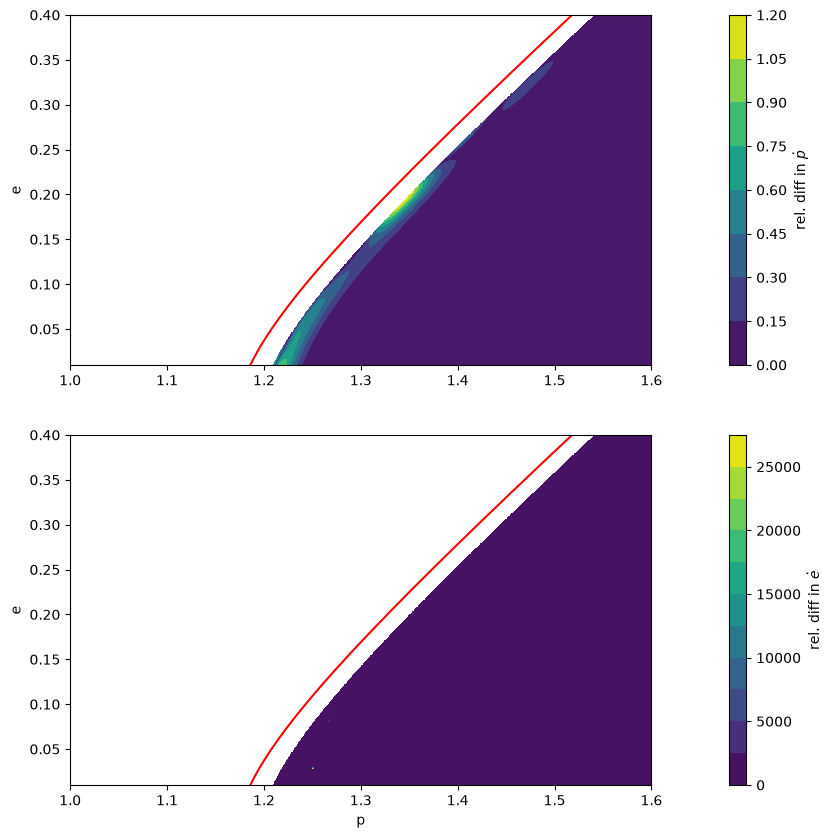

In [39]:
x=1
a=1-10**(-3)
n1,n2 =1000,1000

e = np.linspace(0.01, 0.4, n1)
p= np.linspace(1,1.6,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z_few = (few_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten()))
Z_nex = (nex_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten()))

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_p_few = Z_few[0].reshape(n1,n2)
Z_e_few = Z_few[1].reshape(n1,n2)
Z_p_nex = Z_nex[0].reshape(n1,n2)
Z_e_nex = Z_nex[1].reshape(n1,n2)

Zp_masked_few = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p_few, np.nan)
Ze_masked_few = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e_few, np.nan)
Zp_masked_nex = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p_nex, np.nan)
Ze_masked_nex = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e_nex, np.nan)

rel_diff_p = np.abs((Zp_masked_few-Zp_masked_nex)/(Zp_masked_few))
rel_diff_e = np.abs((Ze_masked_few-Ze_masked_nex)/(Ze_masked_few))

fig, ax = plt.subplots(2,1,figsize = (10,10))

cf1 = ax[0].contourf(P, E, rel_diff_p, levels=10, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"rel. diff in $ \dot{p}$",pad = 0.1)

cf2 = ax[1].contourf(P, E, rel_diff_e, levels=10, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"rel. diff in $ \dot{e}$",pad = 0.1)


#ax[0].set_xlabel("p")
ax[0].set_ylabel("e")
ax[1].set_xlabel("p")
ax[1].set_ylabel("e")

ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")

plt.show()

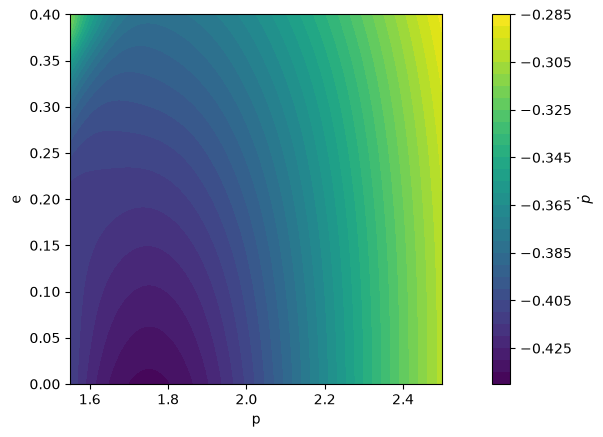

In [38]:
x=1
a = 1-10**(-12)
n1,n2 =100,100
e = np.linspace(0,0.4, n1)

psep_max = max(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)))

p= np.linspace(psep_max+0.15,2.5,n2)
#dp = np.linspace(DELTAPMIN_REGIONC+0.1,6,n1)
#psep = get_separatrix(a,e,np.ones_like(a)*x)
#p = psep+dp

E, P = np.meshgrid(e, p)

Z =nex_pedot(np.ones_like(E).flatten()*a,P.flatten(),E.flatten(),np.ones_like(E).flatten())
Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

fig, ax = plt.subplots()

cf1 = ax.contourf(P, E, Z_p, levels=30, cmap="viridis")
fig.colorbar(cf1, ax=ax, label=r"$\dot{p}$",pad = 0.1)

ax.set_xlabel("p")
ax.set_ylabel("e")



plt.show()

In [ ]:
get_separatrix(a,0.4,1)

In [ ]:
psep_max

# Verify nex_ELdot Function:

In [80]:
import h5py
import pandas as pd

In [81]:
data_in = np.loadtxt('rectilinear_subset.txt')
columns = ["a", "p", "e", "x", "pos", "Edot_tot", "Ldot_tot", "Qdot_tot", "Edot_hor", "Edot_inf", "Ldot_hor", "Ldot_inf", "Qdot_hor", "Qdot_inf", "timing (s)", "iu", "iw", "iz"]
df = pd.DataFrame(data_in, columns=columns)
data_grid = data_in.reshape(8, 9, 9, len(columns))
params_grid = data_grid[:, :, :, :4]

In [124]:
y =[]
yy= []
z =[]
zz= []

for a, p, e , Edot, Ldot in zip(df["a"], df["p"], df["e"], df["Edot_tot"], df["Ldot_tot"]):
    x=1
    E_flux_me, L_flux_me = nex_ELdot(a,p,e,x)
    E_flux_zach = Edot
    L_flux_zach = Ldot

    y.append(-Edot)
    yy.append(E_flux_me)

    z.append(-Ldot)
    zz.append(L_flux_me)

y = np.asarray(y)    
yy = np.asarray(yy) 

z = np.asarray(z)    
zz = np.asarray(zz) 

   # if np.abs(1-(E_flux_me/E_flux_zach)) >= 0.1:
    #    print(E_flux_me,-E_flux_zach)

   # print(E_flux_me,-E_flux_zach)

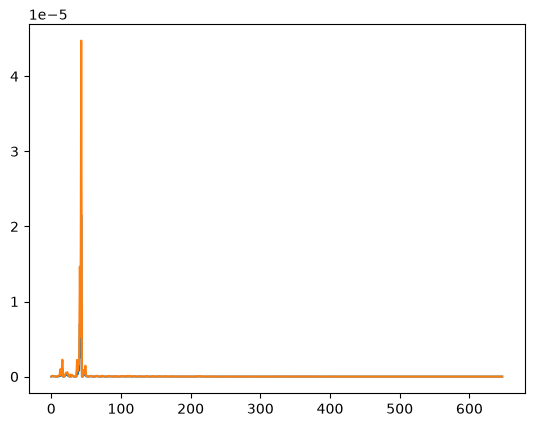

In [127]:
plt.plot(np.abs(y-yy))
plt.plot(np.abs(z-zz))

In [128]:
np.argmax(np.abs(y-yy))

np.int64(43)

In [130]:
(y[43]-yy[43])/y[43]

np.float64(-0.0016715625376499258)